In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from prophet import Prophet
from prophet.plot import plot_plotly
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PROCESSED = Path("../data/processed")
print("Libraries loaded")

Libraries loaded


In [3]:
df = pd.read_csv(PROCESSED / "cihi_wait_times_clean.csv")

# Filter to national level, 50th percentile, calendar years only.
#  Hip and knee replacement are the two most reported procedures

cihi_filtered = df[
    (df["province"] == "Canada")
    & (df["metric"] == "50th Percentile")
    & (df["reporting_level"] == "National")
    & (df["indicator"].isin(["Hip Replacement", "Knee Replacement"]))
    & (df["indicator_result"].notna())
].copy()
# Check which procedures are available after filtering.
# This helps confirm that the filter kept the procedures I expected.
print("Available procedures:")
print(cihi_filtered["indicator"].value_counts())
print()
print("Year range:")
print(f"  {cihi_filtered['data_year'].min()} to {cihi_filtered['data_year'].max()}")
print()
print(cihi_filtered[["indicator", "data_year", "indicator_result"]]
      .sort_values(["indicator", "data_year"])
      .to_string(index=False))

Available procedures:
indicator
Hip Replacement     15
Knee Replacement    15
Name: count, dtype: int64

Year range:
  2010 to 2024

       indicator  data_year  indicator_result
 Hip Replacement       2010         83.000000
 Hip Replacement       2011         90.000000
 Hip Replacement       2012         89.000000
 Hip Replacement       2013         88.000000
 Hip Replacement       2014         88.740000
 Hip Replacement       2015         92.570000
 Hip Replacement       2016         98.190000
 Hip Replacement       2017        104.966879
 Hip Replacement       2018        104.915169
 Hip Replacement       2019        106.224101
 Hip Replacement       2020        165.162222
 Hip Replacement       2021        133.852788
 Hip Replacement       2022        164.325500
 Hip Replacement       2023        130.985343
 Hip Replacement       2024        125.387989
Knee Replacement       2010         99.000000
Knee Replacement       2011        108.000000
Knee Replacement       2012        107.

In [5]:
# ─────────────────────────────────────────────────────────────
# Prophet Forecast Function
# ─────────────────────────────────────────────────────────────
# This function trains a Prophet forecasting model for one CIHI procedure and predicts future wait times for the next few years.
#
# I use a function here because I need to run the same forecasting steps for both Hip Replacement and Knee Replacement without repeating code.

def forecast_procedure(df_cihi, procedure_name: str, forecast_years: int = 3):
    """
    Fit a Prophet time series model on CIHI wait time data and forecast future years with confidence intervals.

    Parameters:
        df_cihi        : filtered CIHI dataframe
        procedure_name : 'Hip Replacement' or 'Knee Replacement'
        forecast_years : how many years ahead to forecast

    Returns:
        model    : fitted Prophet model
        forecast : forecast dataframe
        df_proc  : original data used for training in Prophet format
    """

    # ── Prepare data in Prophet format ────────────────────────
    # Prophet requires exactly two columns:
    #   ds = date column
    #   y  = value to forecast
    #
    # ds must be a datetime column.
    # Since the CIHI data is annual, I use January 1st for each year.
    # For example, 2024 becomes 2024-01-01.

    df_proc = df_cihi[df_cihi["indicator"] == procedure_name].copy()
    df_proc = df_proc.sort_values("data_year").reset_index(drop=True)

    df_prophet = pd.DataFrame({
        "ds": pd.to_datetime(df_proc["data_year"].astype(str) + "-01-01"),
        "y": df_proc["indicator_result"]
    })

 
    print(f"\n=== {procedure_name} ===")
    print(
        f"Training data: {len(df_prophet)} years "
        f"({df_prophet['ds'].dt.year.min()} – {df_prophet['ds'].dt.year.max()})"
    )
    print(
        f"Wait days range: "
        f"{df_prophet['y'].min():.0f} – {df_prophet['y'].max():.0f}"
    )

    # ── Fit Prophet model ──────────────────────────────────────
    # I turn off daily, weekly, and yearly seasonality because this dataset
    # has only one observation per year.
    #
    # yearly_seasonality=False:
    #   There is no monthly/weekly pattern to learn from annual data.
    #
    # changepoint_prior_scale:
    #   Controls how flexible the trend line is.
    #   A higher value lets Prophet react more to trend changes,
    #   which is useful here because wait times changed sharply around 2020.
    #
    # interval_width=0.95:
    #   Gives a 95% uncertainty interval around the forecast.

    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.3,
        interval_width=0.95
    )

    model.fit(df_prophet)

    # ── Generate future dataframe ──────────────────────────────
    # make_future_dataframe extends the time series into future years.
    #
    # periods=forecast_years:
    #   Number of future years to forecast.
    #
    # freq="YS":
    #   Year Start frequency, so future dates will be Jan 1 of each year.

    future = model.make_future_dataframe(
        periods=forecast_years,
        freq="YS"
    )

    forecast = model.predict(future)

    # ── Print forecast for future years only ───────────────────
    # The forecast dataframe includes both historical fitted values and future predicted values.
    # Here I only print years after the last year in the training data.

    future_only = forecast[
        forecast["ds"].dt.year > df_prophet["ds"].dt.year.max()
    ]

    print("\nForecast:")
    print(
        future_only[["ds", "yhat", "yhat_lower", "yhat_upper"]]
        .rename(columns={
            "ds": "year",
            "yhat": "forecast",
            "yhat_lower": "lower_95",
            "yhat_upper": "upper_95"
        })
        .assign(year=lambda x: x["year"].dt.year)
        .round(1)
        .to_string(index=False)
    )

    return model, forecast, df_prophet

In [6]:
hip_model, hip_forecast, hip_train = forecast_procedure(
    cihi_filtered,
    "Hip Replacement",
    forecast_years=3
)

knee_model, knee_forecast, knee_train = forecast_procedure(
    cihi_filtered,
    "Knee Replacement",
    forecast_years=3
)

22:35:19 - cmdstanpy - INFO - Chain [1] start processing



=== Hip Replacement ===
Training data: 15 years (2010 – 2024)
Wait days range: 83 – 165


22:35:22 - cmdstanpy - INFO - Chain [1] done processing
22:35:23 - cmdstanpy - INFO - Chain [1] start processing
22:35:23 - cmdstanpy - INFO - Chain [1] done processing



Forecast:
 year  forecast  lower_95  upper_95
 2025     150.1     122.5     179.8
 2026     155.0     126.6     184.5
 2027     159.8     128.1     189.5

=== Knee Replacement ===
Training data: 15 years (2010 – 2024)
Wait days range: 99 – 198

Forecast:
 year  forecast  lower_95  upper_95
 2025     180.0     143.5     216.7
 2026     185.9     147.1     223.2
 2027     191.9     155.6     228.5


The Prophet models were trained separately for Hip Replacement and Knee Replacement using 15 annual observations from 2010 to 2024. The forecasts suggest that median wait times may continue increasing over the next three years.

For Hip Replacement, the forecast increases from approximately 150 days in 2025 to 160 days in 2027. For Knee Replacement, the forecast increases from approximately 180 days in 2025 to 192 days in 2027. Knee Replacement is consistently forecasted to have longer wait times than Hip Replacement.

Because the dataset contains only annual observations, these forecasts should be interpreted as trend-based estimates rather than exact predictions. The 95% confidence intervals show a wide possible range, which reflects uncertainty in future wait-time patterns.

22:41:39 - cmdstanpy - INFO - Chain [1] start processing
22:41:39 - cmdstanpy - INFO - Chain [1] done processing
22:41:39 - cmdstanpy - INFO - Chain [1] start processing



=== Hip Replacement ===
Training data: 15 years (2010 – 2024)
Wait days range: 83 – 165

Forecast:
 year  forecast  lower_95  upper_95
 2025     150.1     119.1     179.5
 2026     155.0     124.3     189.0
 2027     159.8     130.4     189.6

=== Knee Replacement ===
Training data: 15 years (2010 – 2024)
Wait days range: 99 – 198


22:41:39 - cmdstanpy - INFO - Chain [1] done processing



Forecast:
 year  forecast  lower_95  upper_95
 2025     180.0     144.1     215.2
 2026     185.9     149.6     221.4
 2027     191.9     156.5     231.8


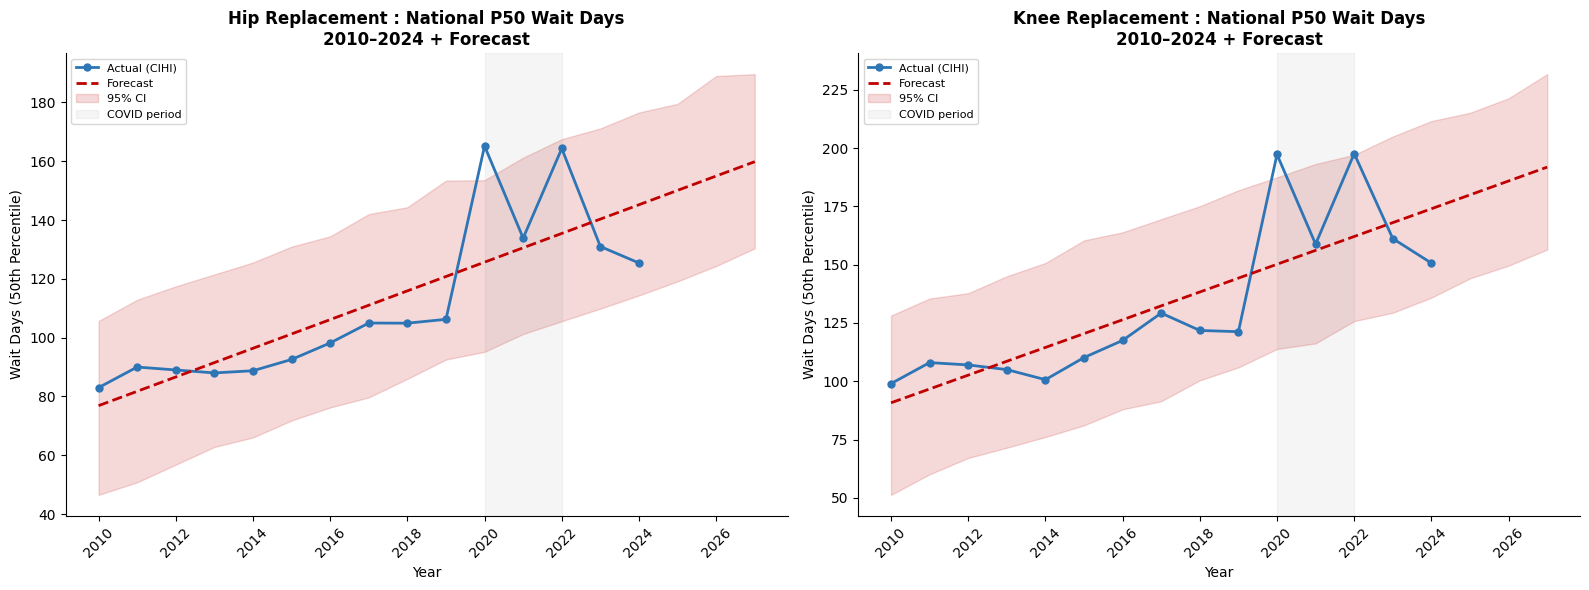

In [8]:
# ─────────────────────────────────────────────────────────────
# forecasts and plot results
# ─────────────────────────────────────────────────────────────
# In this step, I run the Prophet forecast for both procedures and plot the historical CIHI data together with the forecasted trend.
#
# The chart shows:
#   - Actual annual wait times from CIHI
#   - Prophet forecast for the next 3 years
#   - 95% confidence interval
#   - A shaded COVID period for visual context

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, procedure in zip(axes, ["Hip Replacement", "Knee Replacement"]):

    model, forecast, df_train = forecast_procedure(
        cihi_filtered, procedure, forecast_years=3
    )

    # Historical training data
    years   = df_train["ds"].dt.year.values
    actuals = df_train["y"].values

    # Forecast output from Prophet
    fc_years = forecast["ds"].dt.year.values
    fc_yhat  = forecast["yhat"].values
    fc_lower = forecast["yhat_lower"].values
    fc_upper = forecast["yhat_upper"].values

    # ── Actual CIHI data ──────────────────────────────────────
    ax.plot(
        years,
        actuals,
        "o-",
        color="#2E75B6",
        linewidth=2,
        markersize=5,
        label="Actual (CIHI)"
    )

    # ── Forecast line ─────────────────────────────────────────
    ax.plot(
        fc_years,
        fc_yhat,
        "--",
        color="#C00000",
        linewidth=2,
        label="Forecast"
    )

    # ── Confidence interval ───────────────────────────────────
    ax.fill_between(
        fc_years,
        fc_lower,
        fc_upper,
        alpha=0.15,
        color="#C00000",
        label="95% CI"
    )

    # ── COVID period shading ───────────────────────
    ax.axvspan(2020, 2022, alpha=0.08, color="grey", label="COVID period")

    # ── Titles and labels ────────────────────────────────────
    ax.set_title(
        f"{procedure} : National P50 Wait Days\n2010–2024 + Forecast",
        fontsize=12,
        fontweight="bold"
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("Wait Days (50th Percentile)")

    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

The Prophet forecast was fitted separately for Hip Replacement and Knee Replacement using national CIHI 50th percentile wait-time data from 2010 to 2024. The blue line represents the actual CIHI wait-time values, while the red dashed line represents the fitted Prophet trend and the future forecast. The shaded red area shows the 95% uncertainty interval.

Both procedures show relatively stable wait times before 2020, followed by sharp increases during the COVID/backlog period. Although wait times declined in 2023 and 2024, the Prophet trend-based forecast suggests that median wait times may increase again from 2025 to 2027.

Hip Replacement is forecasted to rise from approximately 150 days in 2025 to 160 days in 2027. Knee Replacement is forecasted to rise from approximately 180 days in 2025 to 192 days in 2027. Knee Replacement remains consistently higher than Hip Replacement across both the historical and forecast periods.


In [9]:
# ─────────────────────────────────────────────────────────────
# Trend Analysis: Is the national trend improving or worsening?
# ─────────────────────────────────────────────────────────────
# In this step, I compare the wait-time trend before and after the COVID period.

#
# I exclude 2020 because it was a major disruption year.
# The post-COVID/backlog recovery period is:
#   2021–2024
#
# I use a simple linear regression for each period to estimate the slope, which means the average change in wait days per year.

from scipy import stats

for procedure in ["Hip Replacement", "Knee Replacement"]:

    # Keep only one procedure at a time.
    df_proc = cihi_filtered[
        cihi_filtered["indicator"] == procedure
    ].copy()

    # Split the data into pre-COVID and post-COVID periods.
    pre = df_proc[df_proc["data_year"] <= 2019]      # 2010–2019
    post = df_proc[df_proc["data_year"] >= 2021]     # 2021–2024

    # Run a simple linear regression for each period.
    # slope tells me how many wait days are changing per year.
    slope_pre, _, _, _, _ = stats.linregress(
        pre["data_year"],
        pre["indicator_result"]
    )

    slope_post, _, _, _, _ = stats.linregress(
        post["data_year"],
        post["indicator_result"]
    )

    # Convert the slope into an easy-to-read direction.
    direction_pre = "increasing" if slope_pre > 0 else "decreasing"
    direction_post = "increasing" if slope_post > 0 else "decreasing"

    print(f"=== {procedure} ===")
    print(f"  Pre-COVID trend  (2010–2019): {slope_pre:+.1f} days/year ({direction_pre})")
    print(f"  Post-COVID trend (2021–2024): {slope_post:+.1f} days/year ({direction_post})")
    print()

=== Hip Replacement ===
  Pre-COVID trend  (2010–2019): +2.6 days/year (increasing)
  Post-COVID trend (2021–2024): -5.9 days/year (decreasing)

=== Knee Replacement ===
  Pre-COVID trend  (2010–2019): +2.8 days/year (increasing)
  Post-COVID trend (2021–2024): -6.1 days/year (decreasing)



There is an important tension between the recent trend analysis and the Prophet forecast.

The simple post-COVID trend analysis shows that wait times have been decreasing from 2021 to 2024:

- Hip Replacement: **-5.9 days per year**
- Knee Replacement: **-6.1 days per year**

This suggests that national wait times have been improving in the most recent years.

However, the Prophet forecast still predicts that wait times may increase again from 2025 to 2027. This does not necessarily mean the trend analysis is wrong. Instead, it shows that Prophet is looking at the full 2010–2024 pattern, not only the most recent recovery period.

Across the full time series, wait times increased before COVID, spiked during the backlog period, and then started to decline after 2022. Because there are only 15 annual observations, Prophet may interpret the overall pattern as a long-term upward trend with a temporary disruption, rather than a clear and lasting recovery.

This is an important limitation of the forecast. With only annual data from 2010 to 2024, the model cannot confidently tell whether the recent decline is a true long-term improvement or just a short-term correction after the COVID backlog.

For this reason, the forecast should be interpreted as a trend-based estimate, not a definite prediction. More post-2024 data would be needed to confirm whether wait times are truly continuing to improve or beginning to rise again.